- **Dataset**: [House Prices – Advanced Regression Techniques (Kaggle)](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
    - The dataset and the dataset description are provided in this github folder for your reference.
- **Objective**: Predict sale prices of houses using tabular features (categorical + numerical).  


# Imports & Setup

In [508]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from category_encoders import BinaryEncoder
from xgboost import XGBRegressor
import lightgbm as lgb

from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

from sklearn.decomposition import FastICA

import logging
import joblib

In [509]:
pd.set_option('display.max_columns', None)
#pd.set_option('display.max_rows', None)

In [510]:
#log

logging.basicConfig(
    filename='../logs/app2.log',
    filemode='a',
    level=logging.DEBUG,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', 
    datefmt='%Y-%m-%d %H:%M:%S',  
)

logger = logging.getLogger()



# Data Loading

In [511]:
house = pd.read_csv("../data/house_price_prediction_dataset.csv").drop(["Id"], axis=1)
house.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [512]:
print(house.shape)
house.info()

(1460, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 1

## Utility Functions

In [513]:
# check for missing values in the dataset and return a dataframe with the feature name, count of missing values, 
# percentage of missing values and data type of the feature

def check_missing_values(df):
    missing_feature_counts = df.isna().sum()
    missing_feature_df = (missing_feature_counts[missing_feature_counts >0].to_frame()).reset_index()

    #print(f"total number of missing features: {missing_feature_df.shape[0]}")
    missing_feature_df.columns = ["Feature", "Count"]

    missing_feature_df["null_percentage"] = round((missing_feature_df["Count"]/df.shape[0]) *100, 2)
    missing_feature_df["Type"] = missing_feature_df["Feature"].map(df.dtypes)
    
    return missing_feature_df.sort_values(by="null_percentage", ascending= False)
    
    
def get_dataset_details(df):
    print(f"The dataset contains {df.shape[0]} samples and {df.shape[1]} features(including one target columns)")
    object_columns = df.select_dtypes('object').columns.to_list()
    numerical_columns = df.select_dtypes('number').columns.to_list()
    print(f"The dataset contains {len(numerical_columns)} numerical features and {len(object_columns)} object features")

    missing_features = check_missing_values(df)

    print(f"missing_features:\n {missing_features}")
    logger.info(f"missing_features:\n {missing_features}")

    return {"object_columns": object_columns,
            "numerical_columns": numerical_columns,
            "missing_features": missing_features}


def highly_correlated_features(data, threshold):
    corr_matrix = data.corr().abs().round(2)
    upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k =1).astype(bool))
    high_corr_features = [ (col, row) for col in upper_triangle.columns for row in upper_triangle.index if upper_triangle[col][row] > threshold]
    return high_corr_features

## EDA

- Understand the size of the data
- Basic info of the dataset
- Check if there is any missing features in the dataset
- find highly correlated features
- check highly skewed data

In [514]:
data_details = get_dataset_details(house)

object_columns = data_details["object_columns"]
numerical_columns = data_details["numerical_columns"]
missing_features = data_details["missing_features"]

skewness = house[numerical_columns].skew().sort_values(ascending=False) # using third moment about the mean
highly_skewed_df = skewness[(skewness > 1) | (skewness < -1)]
highly_skewed_columns = skewness[(skewness > 1) | (skewness < -1)].index.to_list()
#mod_skewed_columns = skewness[(skewness > 1) or (skewness <-1) ].index.to_list()

kurtosis = house[numerical_columns].kurtosis().sort_values(ascending=False)
leptokurtic = kurtosis[kurtosis > 0].index.to_list() # heavy tail, higher probability of extreme values

#correlation
threshold = 0.7
high_correlated_features = highly_correlated_features(house[numerical_columns], threshold)


logger.info(f"Total Number of Missing Features:\n {len(missing_features)}\n")
logger.info(f"Missing Features:\n {missing_features}\n")
logger.info("===" * 30)

logger.info("\n Numerical column summary:\n")
logger.info(f"{(house.describe().T).to_string()}\n")

logger.info("===" * 30)
logger.info("\n Skewness:\n")
logger.info(skewness.to_string())

logger.info(f"\n\n No of highly Skewed Features: {len(highly_skewed_columns)}\n")
logger.info(f"\n Highly Skewed Features: {highly_skewed_columns}\n")

logger.info("===" * 30)
logger.info("\n excess Kustosis:\n")
logger.info(f"count= {len(leptokurtic)},\nFeatures= {leptokurtic}\n")

logger.info("===" * 30)
logger.info(f"\n Highly correlated features based on threshold {threshold}:\n {high_correlated_features}")


print(f"Total Number of object colums: {len(object_columns)}")
print(f"Total Number of Numerical colums: {len(numerical_columns)}")
print(f"Total Number of Missing Features: {len(missing_features)}\n")
#print(f"Missing Features:\n {missing_features}\n")
print(f"\n No of highly Skewed Features: {len(highly_skewed_columns)}\n")
print(f"\n Highly Skewed Features: {highly_skewed_columns}\n")

print(f"Heavy Kustosis: count= {len(leptokurtic)},\nFeatures= {leptokurtic}")

print(f"Highly correlated features based on threshold {threshold}: {high_correlated_features}")



The dataset contains 1460 samples and 80 features(including one target columns)
The dataset contains 37 numerical features and 43 object features
missing_features:
          Feature  Count  null_percentage     Type
16        PoolQC   1453            99.52   object
18   MiscFeature   1406            96.30   object
1          Alley   1369            93.77   object
17         Fence   1179            80.75   object
2     MasVnrType    872            59.73   object
10   FireplaceQu    690            47.26   object
0    LotFrontage    259            17.74  float64
11    GarageType     81             5.55   object
12   GarageYrBlt     81             5.55  float64
13  GarageFinish     81             5.55   object
14    GarageQual     81             5.55   object
15    GarageCond     81             5.55   object
8   BsmtFinType2     38             2.60   object
6   BsmtExposure     38             2.60   object
7   BsmtFinType1     37             2.53   object
5       BsmtCond     37            

# Univariate Analysis

- Analyze the distribution of individual features
- Outlier Identification
- Missing value treatment

## Helper function to plot the features

In [515]:
def hist_plot(data):
    no_features = data.shape[1]
    no_cols = 4
    no_rows = (no_features // 4) +1

    fig, axes = plt.subplots(no_rows, no_cols, figsize=(24,no_rows * 6))
    axes = axes.flatten()

    for i, col in enumerate(data.columns.to_list()):
        feature_mean = data[col].mean().round(2)
        feature_median = data[col].median()
        #print(feature_mean, feature_median)

        axes[i].hist(data[col], bins = 20, edgecolor='k')
        axes[i].axvline(feature_mean, color = 'red', linestyle="--", label=f"Mean:{feature_mean}")
        axes[i].axvline(feature_median, color='green', linestyle = "-", label = f"Median:{feature_median}")

        axes[i].set_title(f"Distribution of '{col}'")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")
    
    for j in range(no_features, len(axes)):
        axes[j].set_visible(False)


def box_plot(data):
    no_features = data.shape[1]
    no_cols = 4
    no_rows = (no_features // 4) +1

    fig, axes = plt.subplots(no_rows, no_cols, figsize=(24,no_rows * 6))
    axes = axes.flatten()

    for i, col in enumerate(data.columns.to_list()):
        sns.boxplot(data[col], color='lightblue', ax=axes[i])
        #axes[i].hist(data[col], bins = 20, edgecolor='k')
        axes[i].set_title(f"Boxplot of '{col}'")
        # axes[i].set_xlabel(col)
        # axes[i].set_ylabel("Frequency")
    
    for j in range(no_features, len(axes)):
        axes[j].set_visible(False)


def Numerical_column_distribution(data):
    no_features = data.shape[1]

    fig, axes = plt.subplots(no_features, 2, figsize=(14, no_features * 6))
    
    #axes = axes.flatten()

    for i, col in enumerate(data.columns.to_list()):

        feature_mean = data[col].mean().round(2)
        feature_median = data[col].median()
        #print(feature_mean, feature_median)

        sns.histplot(data[col], bins = 20, edgecolor='k', kde=True, ax=axes[i][0])
        axes[i][0].axvline(feature_mean, color = 'red', linestyle="--", label=f"Mean:{feature_mean}")
        axes[i][0].axvline(feature_median, color='green', linestyle = "-", label = f"Median:{feature_median}")

        axes[i][0].set_title(f"Distribution of '{col}'")
        axes[i][0].set_xlabel(col)
        axes[i][0].set_ylabel("Frequency")


        sns.boxplot(data[col], color='lightblue', ax=axes[i][1])
        #axes[i].hist(data[col], bins = 20, edgecolor='k')
        axes[i][1].set_title(f"Boxplot of '{col}'")
        axes[i][1].set_xlabel(col)
        # axes[i].set_ylabel("Frequency")
    
    for j in range(no_features, len(axes)):
        axes[j].set_visible(False)

## Numerical Column Distribution

In [516]:
#Numerical_column_distribution(house[numerical_columns])

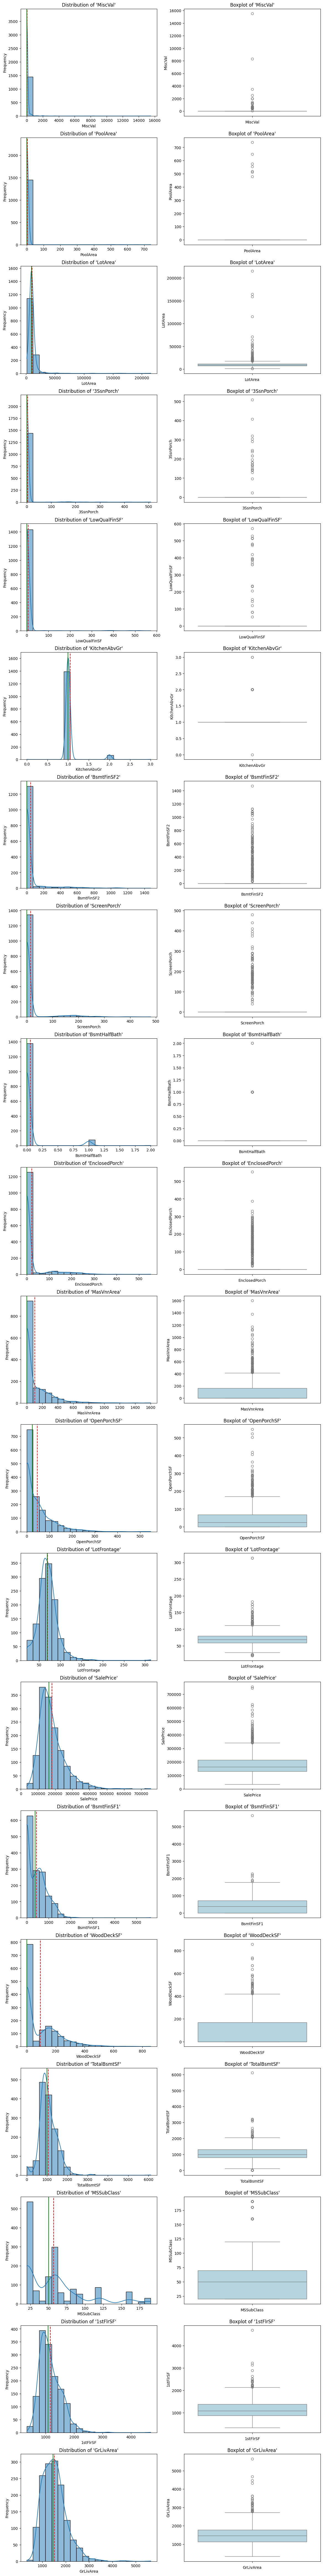

In [517]:
# Check the distribution of highly skewed features using histogram and boxplot
Numerical_column_distribution(house[highly_skewed_columns])

## Categorical Column Distribution

In [518]:
def categorical_column_distribution(data):
    no_features = data.shape[1]
    no_cols = 3
    no_rows = no_features//no_cols +1 
    
    print(no_features)
    fig, axes = plt.subplots(no_rows, no_cols, figsize = (16,70))
    axes = axes.flatten()

    for i, col in enumerate(data.columns.to_list()):
        value_counts = data[col].value_counts()
        #print(value_counts)
        axes[i].bar(value_counts.index, value_counts.values)
        axes[i].set_title(f"Distribution of '{col}'")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(no_features, len(axes)):
        axes[j].set_visible(False)
    

In [519]:
#categorical_column_distribution(house[object_columns])

## Target Distribution

Text(0.5, 1.0, 'SalePrice Distribution')

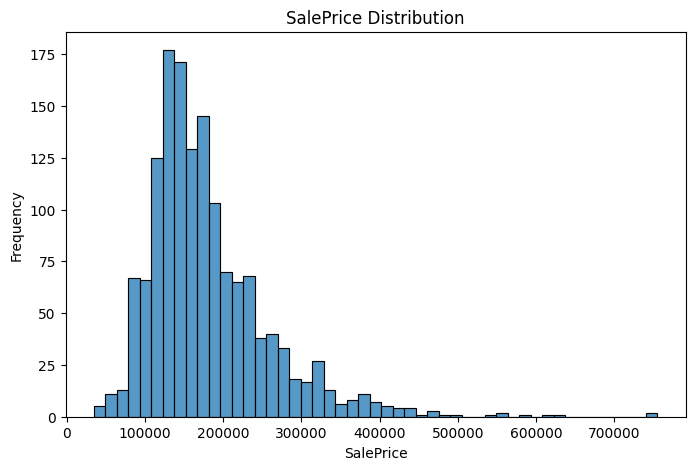

In [520]:
plt.figure(figsize=(8,5))
sns.histplot(house['SalePrice'])
plt.ylabel("Frequency")
plt.title('SalePrice Distribution')
    

Target 'SalePrice' is highly skewed. For linear model we need to log transform the data.

# Bivariate Analysis
- Scatter plot between features and target

In [521]:
house.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [522]:
def distribution_with_target(data, target):
    no_features = data.shape[1]
    no_cols = 3
    no_rows = no_features//no_cols +1 
    
    print(no_features)
    fig, axes = plt.subplots(no_rows, no_cols, figsize = (16,70))
    axes = axes.flatten()

    for i, col in enumerate(data.columns.to_list()):
        sns.scatterplot(data, x=col, y=target, ax=axes[i])
        
        # axes[i].set_title(f"Scatterplot of '{col}'")
        # axes[i].set_xlabel(col)
        # axes[i].set_ylabel(target)

    for j in range(no_features, len(axes)):
        axes[j].set_visible(False)
    

37


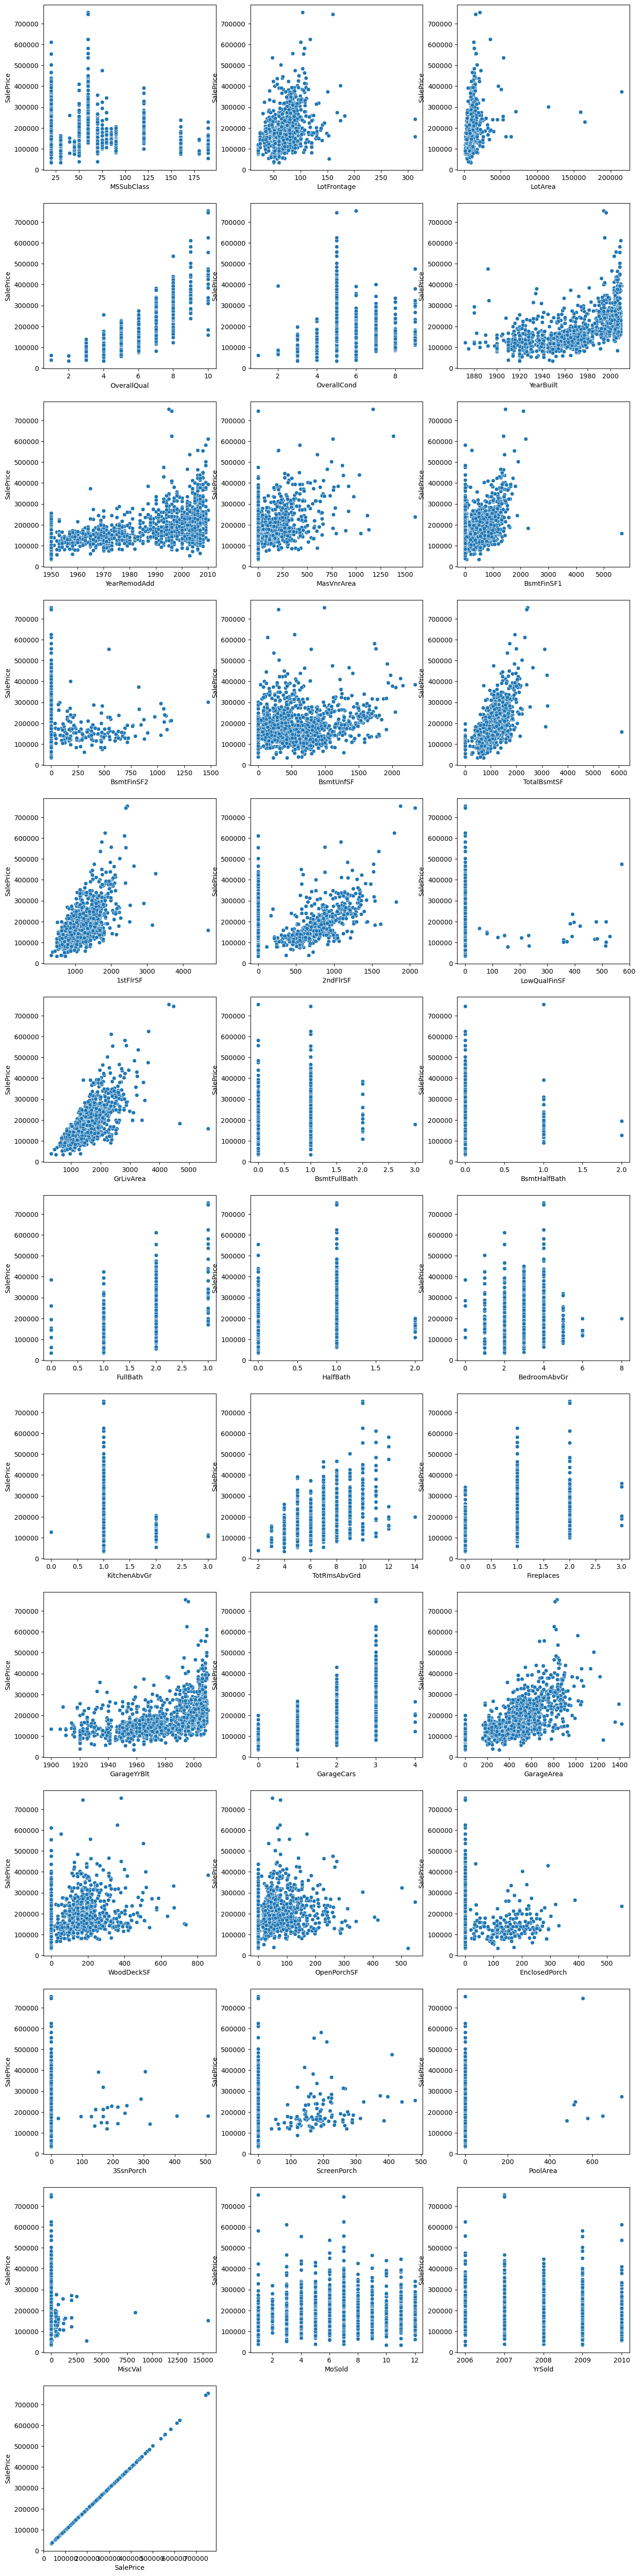

In [523]:
#sns.scatterplot(house, x="TotalSF", y="SalePrice")

distribution_with_target(house[numerical_columns], "SalePrice")

# Feature Engineering & Data Cleanup

<!-- The data contains 1460 samples and 79 features, No of features are quite high. 
We will use Filter methods to determine, 
- low variance fetures from each independent features
- compare variance between groups vs. variance within group - find F-statistics
- MI (Mutual information) - dependency between feature X and target Y -->


In [524]:
def create_new_features(df):
    '''
        This method creates features based on existing feature 
    '''
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['HouseRemodAge'] = df['YrSold']  - df['YearRemodAdd']
    df["TotalSF"] = (df["TotalBsmtSF"] +df["1stFlrSF"] + df["2ndFlrSF"])
    df["TotalBath"] = (df["FullBath"] + 0.5 * df["HalfBath"] + df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"])
    df["TotalPorchArea"] = df["WoodDeckSF"] + df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"]
    return df



#### get columns which has null value count more that 50%

missing_feature_counts = check_missing_values(house)
cols_to_drop = missing_feature_counts[missing_feature_counts["null_percentage"] > 50]["Feature"].to_list()
logger.info(f"Features which contain more than 50% null value: {cols_to_drop}") #['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType']


## find out ouliers in 'GrLivArea'

high_gr_live_area = house[(house["GrLivArea"]>4000)]
#drop rows which are having abnormal price "GrLivArea">4000 but Saleprice ~ mean of saleprice

drop_rows = house[(house["GrLivArea"]>4000) & (house['SalePrice'] <200000)]
house.drop(drop_rows.index, axis=0, inplace=True)

#create new features and drop missing value features
cleaned_df = create_new_features(house)
cleaned_df.drop(cols_to_drop, axis=1, inplace=True)
cleaned_df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,HouseAge,HouseRemodAge,TotalSF,TotalBath,TotalPorchArea
0,60,RL,65.0,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500,5,5,2566,3.5,61
1,20,RL,80.0,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500,31,31,2524,2.5,298
2,60,RL,68.0,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500,7,6,2706,3.5,42
3,70,RL,60.0,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000,91,36,2473,2.0,307
4,60,RL,84.0,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000,8,8,3343,3.5,276


calculate the numeric and object columns after data cleanup

In [525]:
cat_cols = cleaned_df.select_dtypes(include="object").columns.to_list()
num_cols = cleaned_df.select_dtypes(exclude="object").columns.to_list()
print(cat_cols)
print(num_cols)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVa

There are lot of features which seems to be numeric nut actually they are categorical, ex: MSSubClass, OverallQual etc.

Find highly correlated features

In [526]:
highly_correlated_features(house[num_cols], 0.7)


[('1stFlrSF', 'TotalBsmtSF'),
 ('TotRmsAbvGrd', 'GrLivArea'),
 ('GarageYrBlt', 'YearBuilt'),
 ('GarageArea', 'GarageCars'),
 ('SalePrice', 'OverallQual'),
 ('SalePrice', 'GrLivArea'),
 ('HouseAge', 'YearBuilt'),
 ('HouseAge', 'GarageYrBlt'),
 ('HouseRemodAge', 'YearRemodAdd'),
 ('TotalSF', 'TotalBsmtSF'),
 ('TotalSF', '1stFlrSF'),
 ('TotalSF', 'GrLivArea'),
 ('TotalSF', 'SalePrice'),
 ('TotalPorchArea', 'WoodDeckSF')]

highly correlated features to be removed (one from each pair)

#### Find the high cardinalily features

In [527]:
#check cardinality of category columns
for col in cleaned_df.columns:
    cardinality = len(cleaned_df[col].value_counts().index.to_list())
    if (cardinality >10) & (cardinality<30):
        print(f"{col}: {cardinality}")


MSSubClass: 15
Neighborhood: 25
Exterior1st: 15
Exterior2nd: 16
LowQualFinSF: 24
TotRmsAbvGrd: 12
3SsnPorch: 20
MiscVal: 21
MoSold: 12


The category features which has high cardinality can not be encoded with onehotencoding. Already identified category columns(some are numeric as well). 

# Preprocessing +Feature Selection PCA

In [528]:
highly_skewed_df

MiscVal          24.476794
PoolArea         14.828374
LotArea          12.207688
3SsnPorch        10.304342
LowQualFinSF      9.011341
KitchenAbvGr      4.488397
BsmtFinSF2        4.255261
ScreenPorch       4.122214
BsmtHalfBath      4.103403
EnclosedPorch     3.089872
MasVnrArea        2.669084
OpenPorchSF       2.364342
LotFrontage       2.163569
SalePrice         1.882876
BsmtFinSF1        1.685503
WoodDeckSF        1.541376
TotalBsmtSF       1.524255
MSSubClass        1.407657
1stFlrSF          1.376757
GrLivArea         1.366560
dtype: float64

In [529]:
# [np.str_('LotArea'), np.str_('MasVnrArea'), np.str_('BsmtFinSF2'), np.str_('LowQualFinSF'), np.str_('OpenPorchSF'), 
#  np.str_('EnclosedPorch'), np.str_('3SsnPorch'), np.str_('ScreenPorch'), np.str_('PoolArea'), np.str_('MiscVal'), 
#  np.str_('BsmtHalfBath'), np.str_('KitchenAbvGr')]


cat_binary = ["MSSubClass", "Neighborhood", "Exterior1st", "Exterior2nd","MoSold"]

cat_onehotencode = [
    "MSZoning","Street","LotShape","LandContour","Utilities",
    "LotConfig","LandSlope","Condition1","Condition2", "BldgType","HouseStyle","RoofStyle","RoofMatl",
    "Foundation","Heating","CentralAir","Electrical", "GarageType","GarageFinish","PavedDrive", "SaleType","SaleCondition",
    "OverallQual", "OverallCond"]


cat_ordinal = [
    "ExterQual","ExterCond","BsmtQual","BsmtCond","BsmtExposure", "BsmtFinType1","BsmtFinType2","HeatingQC","KitchenQual",
    "Functional","FireplaceQu","GarageQual","GarageCond"]


ordinal_categories = [
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'No', 'Mn', 'Av', 'Gd' ],
    ['Missing', 'Unf', 'LwQ', 'Rec', 'BLQ','ALQ','GLQ' ],
    ['Missing', 'Unf', 'LwQ', 'Rec', 'BLQ','ALQ','GLQ' ],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
]

num_cols = [
    "LotFrontage","BsmtFinSF1", "BsmtUnfSF", "2ndFlrSF", "GrLivArea", "GarageArea","WoodDeckSF", "FullBath","HalfBath",
    "BsmtFullBath", "BedroomAbvGr", "Fireplaces", "TotalBsmtSF", "HouseAge", "HouseRemodAge", "TotalSF", "TotalBath"
    ]       #removed "1stFlrSF","TotRmsAbvGrd", "TotalBsmtSF", "YearBuilt", "GarageCars", "YearRemodAdd" as highly correlated
#"YrSold",

num_cols_highly_skewed = ["MiscVal", "PoolArea", "LotArea", "3SsnPorch", "LowQualFinSF", "KitchenAbvGr", "BsmtFinSF2", "ScreenPorch", "BsmtHalfBath",
                          "EnclosedPorch", "MasVnrArea", "OpenPorchSF"]

all_features = cat_binary + cat_onehotencode + cat_ordinal + num_cols + num_cols_highly_skewed
all_features



['MSSubClass',
 'Neighborhood',
 'Exterior1st',
 'Exterior2nd',
 'MoSold',
 'MSZoning',
 'Street',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'Condition1',
 'Condition2',
 'BldgType',
 'HouseStyle',
 'RoofStyle',
 'RoofMatl',
 'Foundation',
 'Heating',
 'CentralAir',
 'Electrical',
 'GarageType',
 'GarageFinish',
 'PavedDrive',
 'SaleType',
 'SaleCondition',
 'OverallQual',
 'OverallCond',
 'ExterQual',
 'ExterCond',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'HeatingQC',
 'KitchenQual',
 'Functional',
 'FireplaceQu',
 'GarageQual',
 'GarageCond',
 'LotFrontage',
 'BsmtFinSF1',
 'BsmtUnfSF',
 '2ndFlrSF',
 'GrLivArea',
 'GarageArea',
 'WoodDeckSF',
 'FullBath',
 'HalfBath',
 'BsmtFullBath',
 'BedroomAbvGr',
 'Fireplaces',
 'TotalBsmtSF',
 'HouseAge',
 'HouseRemodAge',
 'TotalSF',
 'TotalBath',
 'MiscVal',
 'PoolArea',
 'LotArea',
 '3SsnPorch',
 'LowQualFinSF',
 'KitchenAbvGr',
 'BsmtFinSF2',
 'ScreenPorch',
 'BsmtHalfBath',

In [530]:
from sklearn.preprocessing import FunctionTransformer


target_col = ["SalePrice"]

data = cleaned_df[cat_binary + cat_onehotencode + cat_ordinal + num_cols + num_cols_highly_skewed + target_col]


X = data.drop(["SalePrice"], axis=1) 
y = data["SalePrice"]


# use box-cox transformation for highly skewed data
# from scipy import stats
# for col in highly_skewed_num_cols:
#     data[col] = stats.boxcox(data[col], lmbda=0) #log transform

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
y_train = np.log1p(y_train)
y_test = np.log1p(y_test)



numeric_transformer = Pipeline(
    steps=[
        #('mean_imputer', SimpleImputer(strategy='mean')),
        ('median_imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
        ]
)
numeric_log_transformer = Pipeline(
    steps=[
        #('mean_imputer', SimpleImputer(strategy='mean')),
        ('median_imputer', SimpleImputer(strategy='median')),
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('scaler', StandardScaler())
        ]
)

categorical_binary_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("binaryencoder", BinaryEncoder(handle_unknown='ignore'))
    ])

categorical_onehot_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("onehotencoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("ordinal", OrdinalEncoder(
            categories = ordinal_categories,
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ))
    ]
)


preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('log_num', numeric_log_transformer, num_cols_highly_skewed),
    ('cat_onehotencode', categorical_onehot_transformer, cat_onehotencode),
    ('cat_ordinal', categorical_ordinal_transformer, cat_ordinal),
    ('cat_binary', categorical_binary_transformer, cat_binary)
    #('pass', SimpleImputer(strategy='median'), pass_cols)
])

# # include PCA

pca = PCA(n_components=0.95)
pipeline_pca = Pipeline(
    steps=[
        ('preprocess', preprocessor),
        ('PCA', pca)
    ]
)


logger.info(f"Before transformation shape of X_train scaled: {X_train.shape}")
logger.info(f"Before transformation shape of X_test scaled: {X_test.shape}")

logger.info("==" * 30)
logger.info("preprocess the data using PCA")
X_train_scaled_pca = pipeline_pca.fit_transform(X_train)
X_test_scaled_pca = pipeline_pca.transform(X_test)

logger.info(f"After transformation shape of X_train scaled: {X_train_scaled_pca.shape}")
logger.info(f"After transformation shape of X_test scaled: {X_test_scaled_pca.shape}")

logger.info(f"Explained variance ratio:\n {pca.explained_variance_ratio_}")
logger.info(f"Total Explained variance ratio: {sum(pca.explained_variance_ratio_)}")



## without pca
logger.info("==" * 30)
logger.info("preprocess the data without PCA")
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

logger.info(f"After transformation shape of X_train scaled: {X_train_scaled.shape}")
logger.info(f"After transformation shape of X_test scaled: {X_test_scaled.shape}")

feature_names =[name.split("__")[1] for name in preprocessor.get_feature_names_out()]
logger.info(f"Preprocesed FeatureNames: {feature_names}")




# Baseline model

## Linear Regression

In [531]:
def create_model(preprocessor, model, model_name):
    reggresor = Pipeline(
    steps=[
        ('pre', preprocessor),
        (model_name, model)
    ])
    return reggresor

In [532]:
alpha = 0.005

logger.info(f"Learning rate: {alpha}")
model_pipelines = [("linear_regression", create_model(preprocessor, LinearRegression(tol=0.0001, fit_intercept=True),'linear_regression')), 
                   ("linear_regression_pca", create_model(pipeline_pca, LinearRegression(tol=0.0001, fit_intercept=True), 'linear_regression_pca')),
                   ("linear_regression_ridge", create_model(preprocessor, Ridge(tol=0.0001, alpha=10, fit_intercept=True), 'linear_regression_ridge')),
                   ("linear_regression_ridge_pca", create_model(pipeline_pca, Ridge(tol=0.0001, alpha=alpha, fit_intercept=True), 'linear_regression_ridge_pca')),
                   ("linear_regression_lasso", create_model(preprocessor, Lasso(tol=0.0005, alpha=alpha, fit_intercept=True), 'linear_regression_lasso')),
                   ("linear_regression_lasso_pca", create_model(pipeline_pca, Lasso(tol=0.0001, alpha=alpha, fit_intercept=True), 'linear_regression_lasso_pca')),
                   ("linear_regression_elastinet", create_model(preprocessor, ElasticNet(tol=0.0001, alpha=0.005, l1_ratio=.25, fit_intercept=True),'linear_regression_elastinet')),
                   ("linear_regression_elastinet_pca", create_model(pipeline_pca, ElasticNet(tol=0.0001, alpha=0.005, l1_ratio=.25, fit_intercept=True), 'linear_regression_elastinet_pca'))] 


r2_scores = []

for name, pipe in model_pipelines:
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    y_train_pred = pipe.predict(X_train)


    r2_score_test = r2_score(y_test,y_test_pred)
    r2_score_train = r2_score(y_train, y_train_pred)

    rmse_test = root_mean_squared_error(y_test,y_test_pred)
    rmse_train = root_mean_squared_error(y_train, y_train_pred)  

    r2_scores.append({
                "Model": name, 
                "R2_score-Test": r2_score_test, 
                "R2_score-Train": r2_score_train,
                "RMSE-Test": rmse_test, 
                "RMSE-Train": rmse_train,
                "RMSE-Difference_Test-Train": rmse_test - rmse_train
                })  

logger.info((pd.DataFrame(r2_scores)).to_string())  
    
pd.DataFrame(r2_scores)


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748


In [533]:
model_pipelines[2][1]

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('linear_regression_ridge', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('log_num', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differe

In [534]:
X_train_ridge = preprocessor.fit_transform(X_train)
ridge_regression = Ridge(tol=0.0001, alpha=10, max_iter=10000, fit_intercept=True)

scores = cross_val_score(ridge_regression, X_train_ridge, y_train, cv=5, scoring='neg_root_mean_squared_error')
scores = -scores
print(f"Ridge Regression cross validation root_mean_squared_error: {scores}")
print(f"Mean root_mean_squared_error: {scores.mean()}")

elastinet_regression = ElasticNet(tol=0.0001, alpha=0.0005, max_iter=10000, l1_ratio=.25, fit_intercept=True)

scores1 = cross_val_score(elastinet_regression, X_train_ridge, y_train, cv=5, scoring='neg_root_mean_squared_error')
scores1 = -scores1
print(f"Elastinet Regression cross validation root_mean_squared_error: {scores1}")
print(f"Mean root_mean_squared_error: {scores1.mean()}")


Ridge Regression cross validation root_mean_squared_error: [0.11054951 0.12359535 0.1301388  0.11406624 0.10745428]
Mean root_mean_squared_error: 0.11716083593871633
Elastinet Regression cross validation root_mean_squared_error: [0.11754567 0.12368445 0.12444174 0.11351643 0.10249272]
Mean root_mean_squared_error: 0.11633620139087493


In [535]:
# loaded_model = dump_load_model(model_pipelines[2][1], '../models/lr_ridge_model_with_all_features.joblib')
# predict_test(loaded_model, all_features,  "../data/test.csv", "submission_lr_ridge.csv")

In [536]:
##Features selection as per Lasso regression - Coefficients of all other features except below listed features are 0, 
# that means there is no significant effect on model 

lasso_reg_coefs = model_pipelines[4][1]["linear_regression_lasso"].coef_
lasso_reg_featurenames = model_pipelines[4][1].named_steps["pre"].get_feature_names_out()

#features = list(set([ col.split("__")[1] for col in lasso_reg_featurenames]))
coef_df = pd.DataFrame(np.column_stack((lasso_reg_featurenames, lasso_reg_coefs)), columns=["features", "coefs"]).sort_values(by="coefs", ascending=False)

logger.info(coef_df.to_string())

not_zero_cols = coef_df[coef_df["coefs"] != 0.0]
logger.info(not_zero_cols.to_string())

important_features = pd.DataFrame(set([feature.split("__")[1].split("_")[0] for feature in (not_zero_cols["features"].to_list())]), 
                                  columns=["Imp_Features-Lasso"])

logger.info("Important Features as per lasso")
logger.info(important_features)
important_features

#not_zero_cols

,Imp_Features-Lasso
0,BsmtExposure
1,LotArea
2,Fireplaces
3,TotalSF
4,OverallCond
5,2
6,OpenPorchSF
7,KitchenQual
8,BsmtQual
9,BsmtFinSF1


<Axes: ylabel='features'>

<Figure size 4000x1400 with 0 Axes>

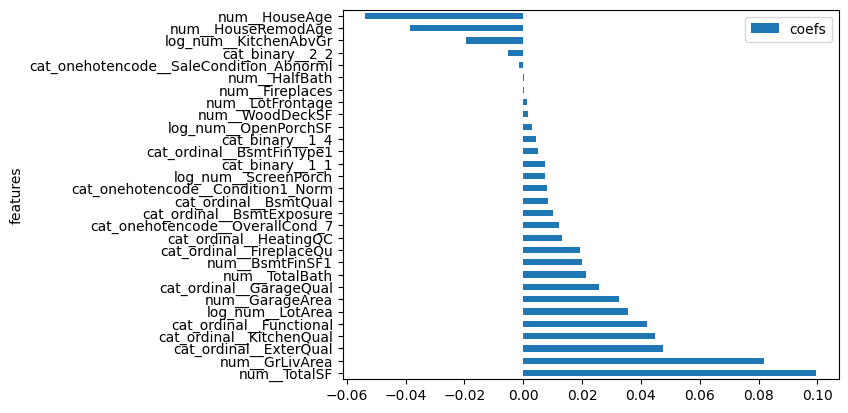

In [537]:
plt.figure(figsize = (40,14))
not_zero_cols.plot(kind='barh', x="features", y = "coefs")

#### ICA (Independent Component Analysis)

In [538]:
ica_rigde_regrssion = Pipeline(
    steps=[
        ("pre", preprocessor),
        ("ica", FastICA(n_components=31,random_state=42, max_iter=100)),
        ("ridge-regression", Ridge(tol=0.0001, alpha=10, fit_intercept=True))
        ])

ica_rigde_regrssion.fit(X_train, y_train)
y_test_pred = ica_rigde_regrssion.predict(X_test)
print(r2_score(y_test, y_test_pred))
print(root_mean_squared_error(y_test, y_test_pred))

0.8724915201389489
0.1466114018415082


## Decision Tree

In [539]:

categorical_binary_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("binaryencoder", BinaryEncoder(handle_unknown='ignore'))
    ])

categorical_onehot_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("onehotencoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("ordinal", OrdinalEncoder(
            categories = ordinal_categories,
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ))
    ]
)

preprocessor_decision_tree = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols+num_cols_highly_skewed),
    ('cat_onehotencode', categorical_onehot_transformer, cat_onehotencode),
    ('cat_ordinal', categorical_ordinal_transformer, cat_ordinal),
    ('cat_binary', categorical_binary_transformer, cat_binary)
    #('pass', SimpleImputer(strategy='median'), pass_cols)
])

#min_samples_split = 20

decision_tree_regrssor = Pipeline(
    steps=[
        ("pre", preprocessor_decision_tree),
        ("decision_tree", DecisionTreeRegressor(min_samples_leaf=20, random_state=42))
    ]
)

model_decision_tree = decision_tree_regrssor.fit(X_train, y_train)

y_test_pred = model_decision_tree.predict(X_test)
y_train_pred = model_decision_tree.predict(X_train)


r2_score_test = r2_score(y_test,y_test_pred)
r2_score_train = r2_score(y_train, y_train_pred)

rmse_test = root_mean_squared_error(y_test,y_test_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)  

r2_scores.append({
            "Model": "Decision Tree", 
            "R2_score-Test": r2_score_test, 
            "R2_score-Train": r2_score_train,
            "RMSE-Test": rmse_test, 
            "RMSE-Train": rmse_train,
            "RMSE-Difference_Test-Train": rmse_test - rmse_train
            })  
    
    

logger.info((pd.DataFrame(r2_scores)).to_string())  
pd.DataFrame(r2_scores)


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748
8,Decision Tree,0.767456,0.858158,0.197993,0.149431,0.048563


In [540]:
len(model_decision_tree[0].get_feature_names_out())

198

In [541]:
# from sklearn.tree import plot_tree

# plot_tree(model_decision_tree[1])

mean_squared_error(y_test,y_test_pred)

0.039201388576031

In [542]:
model_decision_tree

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('decision_tree', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehotencode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [543]:

feature_names_dt =[name.split("__")[1] for name in preprocessor_decision_tree.get_feature_names_out()]
logger.info(f"Decision Tree Preprocesed FeatureNames: {feature_names_dt}")

feature_importance_dt = model_decision_tree["decision_tree"].feature_importances_
feature_importance_df = pd.DataFrame({
                            "Feature": feature_names_dt, "importance": feature_importance_dt
                            }).sort_values(by='importance', ascending= False)

high_imp_features = feature_importance_df[feature_importance_df['importance'] >0]
#model_decision_tree_pca.feature_importances_.round(3)

logger.info(f"Feature Importance as per Decision Tree: Count: {len(high_imp_features)}")
logger.info(high_imp_features.to_string())

print("Feature Importance as per Decision Tree")
print(high_imp_features.to_string())

Feature Importance as per Decision Tree
               Feature  importance
15             TotalSF    0.769473
163          ExterQual    0.060486
109       CentralAir_Y    0.036941
13            HouseAge    0.035733
14       HouseRemodAge    0.019971
5           GarageArea    0.018938
22        KitchenAbvGr    0.012888
16           TotalBath    0.007407
165           BsmtQual    0.007049
4            GrLivArea    0.006008
19             LotArea    0.005342
1           BsmtFinSF1    0.004745
147      OverallQual_4    0.003490
2            BsmtUnfSF    0.003394
0          LotFrontage    0.002269
3             2ndFlrSF    0.001620
151      OverallQual_8    0.001301
120  GarageType_Detchd    0.001110
195                4_1    0.000746
12         TotalBsmtSF    0.000615
173        FireplaceQu    0.000389
28         OpenPorchSF    0.000086


# Advance Regression

### Random Forest

In [544]:

categorical_binary_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("binaryencoder", BinaryEncoder(handle_unknown='ignore'))
    ])

categorical_onehot_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        #("onehotencoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ("binary_encoding", BinaryEncoder(handle_unknown='ignore'))
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("ordinal", OrdinalEncoder(
            categories = ordinal_categories,
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ))
    ]
)

rf_preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols+num_cols_highly_skewed),
    ('cat_onehotencode', categorical_onehot_transformer, cat_onehotencode),
    ('cat_ordinal', categorical_ordinal_transformer, cat_ordinal),
    ('cat_binary', categorical_binary_transformer, cat_binary)
    #('pass', SimpleImputer(strategy='median'), pass_cols)
])

n_estimators = 200
max_depth = 8
min_samples_split = 20

random_forest_regressor = Pipeline(
    steps=[
        ("pre", rf_preprocessor),
        ("random_forest", RandomForestRegressor(n_estimators=n_estimators,  
                                                max_depth=max_depth, 
                                                min_samples_split=min_samples_split, 
                                                oob_score=True,
                                                random_state=42))
    ]
)

random_forest_regressor.fit(X_train, y_train)
y_test_pred = random_forest_regressor.predict(X_test)
y_train_pred = random_forest_regressor.predict(X_train)


r2_score_test = r2_score(y_test,y_test_pred)
r2_score_train = r2_score(y_train, y_train_pred)

rmse_test = root_mean_squared_error(y_test,y_test_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)  

r2_scores.append({
            "Model": "Random Forst Regressor", 
            "R2_score-Test": r2_score_test, 
            "R2_score-Train": r2_score_train,
            "RMSE-Test": rmse_test, 
            "RMSE-Train": rmse_train,
            "RMSE-Difference_Test-Train": rmse_test - rmse_train
            })  

logger.info(f"n_estimators: {n_estimators}, max_depth: {max_depth}, min_samples_split: {min_samples_split}")
logger.info((pd.DataFrame(r2_scores)).to_string())  

pd.DataFrame(r2_scores)


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748
8,Decision Tree,0.767456,0.858158,0.197993,0.149431,0.048563
9,Random Forst Regressor,0.851816,0.936487,0.158051,0.099993,0.058059


In [545]:
#cross_validate(random_forest_regressor)

In [546]:
oob_error = 1 - random_forest_regressor["random_forest"].oob_score_
oob_error

0.1332057010054556

In [547]:
random_forest_regressor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('random_forest', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehotencode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differen

In [548]:

feature_names_dt =[name.split("__")[1] for name in rf_preprocessor.get_feature_names_out()]
logger.info(f"Random Forest Tree Preprocesed FeatureNames: {feature_names_dt}")

feature_importance_rf = random_forest_regressor["random_forest"].feature_importances_
feature_importance_df = pd.DataFrame({
                            "Feature": feature_names_dt, 
                            "importance_rf": feature_importance_rf
                            }).sort_values(by='importance_rf', ascending= False)

high_imp_features = feature_importance_df[(feature_importance_df['importance_rf'] > 0)]
#model_decision_tree_pca.feature_importances_.round(3)

logger.info(f"Feature Importance as per Random Forest: Count: {len(high_imp_features)}")
logger.info(high_imp_features.to_string())
print(feature_importance_df.to_string())

           Feature  importance_rf
15         TotalSF       0.680641
13        HouseAge       0.045982
5       GarageArea       0.038694
102      ExterQual       0.036352
110    KitchenQual       0.031759
14   HouseRemodAge       0.019241
16       TotalBath       0.018799
104       BsmtQual       0.018263
19         LotArea       0.009436
4        GrLivArea       0.008025
75            15_1       0.007850
1       BsmtFinSF1       0.006335
74            15_0       0.006077
2        BsmtUnfSF       0.005933
112    FireplaceQu       0.004293
12     TotalBsmtSF       0.003836
22    KitchenAbvGr       0.003569
114     GarageCond       0.003541
28     OpenPorchSF       0.003034
3         2ndFlrSF       0.003029
0      LotFrontage       0.002816
111     Functional       0.002763
95            22_1       0.002120
107   BsmtFinType1       0.002105
84            18_2       0.002087
11      Fireplaces       0.001769
26   EnclosedPorch       0.001394
91            21_0       0.001313
113     Garage

### XGBoost

In [549]:

categorical_binary_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("binaryencoder", BinaryEncoder(handle_unknown='ignore'))
    ])

categorical_onehot_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("onehotencoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("ordinal", OrdinalEncoder(
            categories = ordinal_categories,
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ))
    ]
)

xgb_preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols+num_cols_highly_skewed),
    ('cat_onehotencode', categorical_onehot_transformer, cat_onehotencode),
    ('cat_ordinal', categorical_ordinal_transformer, cat_ordinal),
    ('cat_binary', categorical_binary_transformer, cat_binary)
    #('pass', SimpleImputer(strategy='median'), pass_cols)
])

xgboost_regressor = Pipeline(
    steps=[
        ("pre", xgb_preprocessor),
        ("xgb", XGBRegressor(
                eval_metric='rmse', 
                max_depth = 4, 
                n_estimators=200, 
                learning_rate=0.05, 
                random_state=42
                ))
    ]
)


xgboost_regressor.fit(X_train, y_train)
y_test_pred = xgboost_regressor.predict(X_test)
y_train_pred = xgboost_regressor.predict(X_train)


r2_score_test = r2_score(y_test,y_test_pred)
r2_score_train = r2_score(y_train, y_train_pred)

rmsle_test = root_mean_squared_error(y_test,y_test_pred)
rmsle_train = root_mean_squared_error(y_train, y_train_pred)  


r2_scores.append({
            "Model": "XGBoostRegressor", 
            "R2_score-Test": r2_score_test, 
            #"Adjusted-R2-Score": 1 - (((X_test.shape[0] - 1) *(1-r2_score_test))/(X_test.shape[0]-X_test.shape[1]-1)),
            "R2_score-Train": r2_score_train,
            "RMSE-Test": rmsle_test, 
            "RMSE-Train": rmsle_train,
            "RMSE-Difference_Test-Train": rmse_test - rmse_train
            })  

#logger.info(f"n_estimators: {n_estimators}, max_depth: {max_depth}, min_samples_split: {min_samples_split}")
logger.info((pd.DataFrame(r2_scores)).to_string()) 
    
pd.DataFrame(r2_scores)


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748
8,Decision Tree,0.767456,0.858158,0.197993,0.149431,0.048563
9,Random Forst Regressor,0.851816,0.936487,0.158051,0.099993,0.058059


In [550]:
scores = cross_val_score(xgboost_regressor, 
                        X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')

rmse_scores = -scores
print(f"Cross validation Root Mean Squared log error: {rmse_scores}")
print("Mean Score: {:.4f}".format(rmse_scores.mean()))

Cross validation Root Mean Squared log error: [0.12041125 0.12809425 0.13950417 0.13471433 0.12111618]
Mean Score: 0.1288


In [551]:
xgboost_regressor

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehotencode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

#### Find important features

In [552]:
def feature_importance(model, preprocessor, top_count = None):
    feature_imp = model.feature_importances_
    feature_names =[name.split("__")[1] for name in preprocessor.get_feature_names_out()]
    feature_names = [name.split("_")[0] for name in feature_names]
    feature_imp_df = pd.DataFrame({
                                "Feature": feature_names, 
                                "importance_xgb": feature_imp
                                }).sort_values(by='importance_xgb', ascending= False)

    if top_count:
        top_imp_features_df = feature_imp_df.iloc[:top_count, :]
    else:
        top_imp_features_df = feature_imp_df
    print(top_imp_features_df.to_string())
    logger.info(top_imp_features_df)

    top_imp_features = top_imp_features_df["Feature"].to_list()
    #print(top_20_imp_features)
    logger.info(top_imp_features)
    
    return top_imp_features_df

In [553]:
top_imp_features = feature_importance(xgboost_regressor["xgb"], xgb_preprocessor, 35)
print(set(top_imp_features["Feature"].to_list()))

           Feature  importance_xgb
163      ExterQual        0.201336
15         TotalSF        0.175299
171    KitchenQual        0.064808
165       BsmtQual        0.059568
108     CentralAir        0.046775
175     GarageCond        0.032814
16       TotalBath        0.031824
22    KitchenAbvGr        0.023136
173    FireplaceQu        0.022751
5       GarageArea        0.018280
33        MSZoning        0.014901
125   GarageFinish        0.013577
121     GarageType        0.013510
13        HouseAge        0.012183
14   HouseRemodAge        0.010902
32        MSZoning        0.010497
39        LotShape        0.010045
11      Fireplaces        0.009181
183              1        0.008319
174     GarageQual        0.007150
179              0        0.007117
116     GarageType        0.006857
147    OverallQual        0.006734
168   BsmtFinType1        0.006657
151    OverallQual        0.006441
4        GrLivArea        0.005797
103        Heating        0.005779
156    OverallCond  

### Hyperparameter tuning

In [554]:

xgb_params ={
        "xgb__n_estimators": randint(300, 1000),
        "xgb__max_depth": randint(3, 10),
        "xgb__min_samples_split": randint(4, 10),
        "xgb__learning_rate": uniform(0.01, 0.2), 
        'xgb__subsample': uniform(0.6, 0.4),
        'xgb__colsample_bytree': uniform(0.6, 0.4),
        'xgb__reg_alpha': uniform(0, 1),
        'xgb__reg_lambda': uniform(0.5, 2)
    }

xgboost_regressor = Pipeline(
    steps=[
        ("pre", xgb_preprocessor),
        ("xgb", XGBRegressor(random_state=42))
    ]
)

random_search = RandomizedSearchCV(
    xgboost_regressor,
    param_distributions=xgb_params,
    n_iter=50,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1,
    
)

random_search.fit(X_train, y_train)

best_params = random_search.best_params_
print(f"Best param: {best_params}")
print(f"Best CV accuracy: {random_search.best_score_}")

best_xgboost = random_search.best_estimator_

print(f"Best rmse: {root_mean_squared_error(y_test, best_xgboost.predict(X_test))}")

y_test_pred = best_xgboost.predict(X_test)
y_train_pred = best_xgboost.predict(X_train)


r2_score_test = r2_score(y_test,y_test_pred)
r2_score_train = r2_score(y_train, y_train_pred)

rmse_test = root_mean_squared_error(y_test,y_test_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)  

r2_scores.append({
            "Model": "Best XGBoostRegressor", 
            "R2_score-Test": r2_score_test, 
            "R2_score-Train": r2_score_train,
            "RMSE-Test": rmse_test, 
            "RMSE-Train": rmse_train,
            "RMSE-Difference_Test-Train": rmse_test - rmse_train,
            #"Adjusted-R2-Score": 1 - (((X_test.shape[0] - 1) *(1-r2_score_test))/(X_test.shape[0]-X_test.shape[1]-1))
            })  

    
    
pd.DataFrame(r2_scores)


/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:08:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:08:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:08:21] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/sumana/Desktop/DataScience-AIML-2025/Da

Best param: {'xgb__colsample_bytree': np.float64(0.8920157266247274), 'xgb__learning_rate': np.float64(0.01954322553832976), 'xgb__max_depth': 4, 'xgb__min_samples_split': 6, 'xgb__n_estimators': 385, 'xgb__reg_alpha': np.float64(0.014393488629755868), 'xgb__reg_lambda': np.float64(0.7321452810138325), 'xgb__subsample': np.float64(0.618401056808701)}
Best CV accuracy: -0.12416919655977006
Best rmse: 0.12743217065468382


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748
8,Decision Tree,0.767456,0.858158,0.197993,0.149431,0.048563
9,Random Forst Regressor,0.851816,0.936487,0.158051,0.099993,0.058059


In [555]:
best_xgboost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('pre', ...), ('xgb', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat_onehotencode', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transfor

In [556]:

def dump_load_model(model, model_path):
    joblib.dump(model, model_path)
    loaded_model = joblib.load(model_path)

    return loaded_model


def predict_test(model, features, test_file, outfile):
    test_df = pd.read_csv(test_file)
  
    test_df_id = test_df.drop(["Id"], axis=1)
    #print(cols_to_drop)
    test_df_cleaned = create_new_features(test_df_id)

    test_pred_log = model.predict(test_df_cleaned[features])
    test_pred = np.expm1(test_pred_log)

    test_pred_df = pd.DataFrame({"Id": test_df["Id"], "SalePrice": test_pred})

    test_pred_df.to_csv(outfile, index=False)

In [557]:
loaded_model = dump_load_model(best_xgboost, '../models/best_xgboost_model_with_all_features.joblib')
predict_test(best_xgboost, all_features, "../data/test.csv", "../data/submission_best_xgboost.csv")


In [558]:
top_imp_features = feature_importance(best_xgboost["xgb"], xgb_preprocessor, 41)
print(set(top_imp_features["Feature"].to_list()))

           Feature  importance_xgb
163      ExterQual        0.191067
15         TotalSF        0.121407
171    KitchenQual        0.053342
109     CentralAir        0.038152
165       BsmtQual        0.037330
108     CentralAir        0.028622
16       TotalBath        0.026085
175     GarageCond        0.022018
173    FireplaceQu        0.017403
13        HouseAge        0.017000
22    KitchenAbvGr        0.016783
5       GarageArea        0.015962
174     GarageQual        0.012818
14   HouseRemodAge        0.012526
7         FullBath        0.011531
4        GrLivArea        0.010344
125   GarageFinish        0.009540
32        MSZoning        0.009417
12     TotalBsmtSF        0.009068
11      Fireplaces        0.007790
151    OverallQual        0.007778
147    OverallQual        0.007762
87       RoofStyle        0.007744
33        MSZoning        0.007437
121     GarageType        0.007374
156    OverallCond        0.006674
52       LandSlope        0.006641
172     Functional  

#### XGBoost with reduced Features

In [559]:
best_params.items()

dict_items([('xgb__colsample_bytree', np.float64(0.8920157266247274)), ('xgb__learning_rate', np.float64(0.01954322553832976)), ('xgb__max_depth', 4), ('xgb__min_samples_split', 6), ('xgb__n_estimators', 385), ('xgb__reg_alpha', np.float64(0.014393488629755868)), ('xgb__reg_lambda', np.float64(0.7321452810138325)), ('xgb__subsample', np.float64(0.618401056808701))])

In [560]:

cat_binary = ["MSSubClass", "Neighborhood", "Exterior1st", "Exterior2nd","MoSold"]

cat_ordinal = ["BsmtQual", "KitchenQual", "ExterQual", "GarageCond", "FireplaceQu", "GarageQual",  
               "Functional", "BsmtCond"]
cat_onehotencode = ["CentralAir", "HouseStyle", "GarageFinish", "MSZoning", "Electrical", "LandContour", "RoofStyle", 
                    "GarageType","BldgType", "Condition1", 
                    "LandSlope", "OverallQual", "PavedDrive", "OverallCond"]
 
num_cols = ["TotalSF", "KitchenAbvGr", "HouseAge", "HouseRemodAge", "TotalBath",
            "GrLivArea", "BsmtFinSF1", "PoolArea", "2ndFlrSF", 
            "GarageArea", "Fireplaces", "BsmtHalfBath"
            #"GarageCars", 
            ]



ordinal_categories = [
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    ['Missing', 'Sal', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    ['Missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex']
]


# num_cols = [
#     "LotFrontage","LotArea","MasVnrArea", "BsmtFinSF1","BsmtFinSF2","BsmtUnfSF","TotalBsmtSF", "1stFlrSF","2ndFlrSF","LowQualFinSF","GrLivArea",
#     "GarageArea","WoodDeckSF","OpenPorchSF","EnclosedPorch", "3SsnPorch","ScreenPorch","PoolArea","MiscVal","FullBath","HalfBath",
#     "BsmtFullBath","BsmtHalfBath","BedroomAbvGr","KitchenAbvGr", "TotRmsAbvGrd","Fireplaces","GarageCars", "HouseAge","HouseRemodAge","TotalSF","TotalBath"
# ]

categorical_binary_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("binaryencoder", BinaryEncoder(handle_unknown='ignore'))
    ])

categorical_onehot_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("onehotencoder", OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("ordinal", OrdinalEncoder(
            categories = ordinal_categories,
            handle_unknown='use_encoded_value', 
            unknown_value=-1
        ))
    ]
)

xgb_preprocessor = ColumnTransformer(transformers=[
    ('num', SimpleImputer(strategy='median'), num_cols),
    ('cat_onehotencode', categorical_onehot_transformer, cat_onehotencode),
    ('cat_ordinal', categorical_ordinal_transformer, cat_ordinal),
    #('pass', SimpleImputer(strategy='median'), pass_cols)
])


xgboost_regressor_best = Pipeline(
    steps=[
        ("pre", xgb_preprocessor),
        ("xgb", XGBRegressor(
                **{k.split("__")[1]: v for k, v in best_params.items()},
                eval_metric='rmse', 
                # max_depth = 6, 
                # n_estimators=500, 
                # min_samples_split=10, 
                # learning_rate=0.05, 
                random_state=42
                ))
    ]
)


xgboost_regressor_best.fit(X_train[cat_ordinal+cat_onehotencode+num_cols], y_train)
y_test_pred = xgboost_regressor_best.predict(X_test[cat_ordinal+cat_onehotencode+num_cols])
y_train_pred = xgboost_regressor_best.predict(X_train[cat_ordinal+cat_onehotencode+num_cols])


r2_score_test = r2_score(y_test,y_test_pred)
r2_score_train = r2_score(y_train, y_train_pred)

rmse_test = root_mean_squared_error(y_test,y_test_pred)
rmse_train = root_mean_squared_error(y_train, y_train_pred)  

r2_scores.append({
            "Model": "XGBoostRegressor - BestParams - Reduced Features", 
            "R2_score-Test": r2_score_test, 
            "R2_score-Train": r2_score_train,
            "RMSE-Test": rmse_test, 
            "RMSE-Train": rmse_train,
            "RMSE-Difference_Test-Train": rmse_test - rmse_train,
            #"Adjusted-R2-Score": 1 - (((X_test.shape[0] - 1) *(1-r2_score_test))/(X_test.shape[0]-X_test.shape[1]-1)),
            })  

#logger.info(f"n_estimators: {n_estimators}, max_depth: {max_depth}, min_samples_split: {min_samples_split}")
logger.info((pd.DataFrame(r2_scores)).to_string()) 
    
pd.DataFrame(r2_scores)


/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [21:08:36] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "min_samples_split" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748
8,Decision Tree,0.767456,0.858158,0.197993,0.149431,0.048563
9,Random Forst Regressor,0.851816,0.936487,0.158051,0.099993,0.058059


### LightGBM

In [561]:

categorical_binary_transformer = Pipeline(
    steps=[('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("binaryencoder", BinaryEncoder(handle_unknown='ignore'))
    ])

numeric_transformer = Pipeline(
    steps=[
        ('mean_imputer', SimpleImputer(strategy='mean'))
        ]
)

categorical_onehot_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("onehotencoder", OneHotEncoder(drop="first", handle_unknown='ignore', sparse_output=False))
    ]
)

categorical_ordinal_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
        ("ordinal", OrdinalEncoder(
            categories= ordinal_categories,
            handle_unknown='use_encoded_value', 
            unknown_value=-1))
    ]
)

lgb_preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, num_cols),
    ('cat_onehotencode', categorical_onehot_transformer, cat_onehotencode),
    ('cat_ordinal', categorical_ordinal_transformer, cat_ordinal),
    ('cat_binary', categorical_binary_transformer, cat_binary)
    #('pass', SimpleImputer(strategy='median'), pass_cols)
])


lgb_regressor = Pipeline(
    steps=[
        ("pre", lgb_preprocessor),
        ("LGBM Regressor", lgb.LGBMRegressor(
                n_estimators=500, 
                learning_rate=0.05, 
                random_state=42
                ))
    ]
)


lgb_regressor.fit(X_train, y_train)
y_test_pred = lgb_regressor.predict(X_test)
y_train_pred = lgb_regressor.predict(X_train)


r2_score_test = r2_score(y_test,y_test_pred)
r2_score_train = r2_score(y_train, y_train_pred)

r2_scores.append({
            "Model": "lgb_regressor", 
            "R2_score-Test": r2_score_test, 
            "R2_score-Train": r2_score_train,
            "RMSE-Test": root_mean_squared_error(y_test,y_test_pred), 
            "RMSE-Train": root_mean_squared_error(y_train, y_train_pred),
            "RMSE-Difference_Test-Train": rmse_test - rmse_train
            })  

    
logger.info((pd.DataFrame(r2_scores)).to_string()) 
pd.DataFrame(r2_scores)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001556 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1538
[LightGBM] [Info] Number of data points in the train set: 1166, number of used features: 84
[LightGBM] [Info] Start training from score 12.023362


/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:261: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/sumana/Desktop/DataScience-AIML-2025/DataScience-AI-ML-2025-Sumana/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


,Model,R2_score-Test,R2_score-Train,RMSE-Test,RMSE-Train,RMSE-Difference_Test-Train
0,linear_regression,0.905147,0.943912,0.126452,0.093966,0.032485
1,linear_regression_pca,0.871949,0.905379,0.146923,0.122048,0.024875
2,linear_regression_ridge,0.906310,0.936487,0.125674,0.099993,0.025681
3,linear_regression_ridge_pca,0.871950,0.905379,0.146923,0.122048,0.024875
4,linear_regression_lasso,0.872707,0.895638,0.146488,0.128177,0.018311
5,linear_regression_lasso_pca,0.868892,0.889301,0.148667,0.132011,0.016656
6,linear_regression_elastinet,0.898671,0.922445,0.130697,0.110495,0.020202
7,linear_regression_elastinet_pca,0.873448,0.903409,0.146060,0.123312,0.022748
8,Decision Tree,0.767456,0.858158,0.197993,0.149431,0.048563
9,Random Forst Regressor,0.851816,0.936487,0.158051,0.099993,0.058059


# Conclusion 
Ridge regression and XGBoost regression, both are resulting Test R2 score 0.90, however Ridge regression is resulting in Root Mean Squared error as 0.1256 (as target it log transformed) which is best based on all the regressor. On the other hand XGBoost train R2 score is resulting better which tends to overfitting.


## Saving and loading model using joblib

In [562]:

def dump_load_model(model, model_path):
    joblib.dump(model, model_path)
    loaded_model = joblib.load(model_path)

    return loaded_model


def predict_test(model, features, test_file, outfile):
    test_df = pd.read_csv(test_file)
  
    test_df_id = test_df.drop(["Id"], axis=1)
    #print(cols_to_drop)
    test_df_cleaned = create_new_features(test_df_id, cols_to_drop)

    test_pred_log = model.predict(test_df_cleaned[features])
    test_pred = np.expm1(test_pred_log)

    test_pred_df = pd.DataFrame({"Id": test_df["Id"], "SalePrice": test_pred})

    test_pred_df.to_csv(outfile, index=False)